In [111]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install seaborn
!pip install scikit-optimize


In [112]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
#from xgboost import XGBRegressor
from sklearn.cluster import KMeans 
from sklearn.preprocessing import StandardScaler


In [113]:
df = pd.read_csv('insurance.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [114]:
# change variables from object to categorical 
df['sex'] = df['sex'].map({'male': 1, 'female': 0})
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   bool   
 7   region_southeast  1338 non-null   bool   
 8   region_southwest  1338 non-null   bool   
dtypes: bool(3), float64(2), int64(4)
memory usage: 66.8 KB


EXPLORATORY DATA ANALYSIS 

Mean age: 39.20702541106129, Max age: 64, Min age: 18


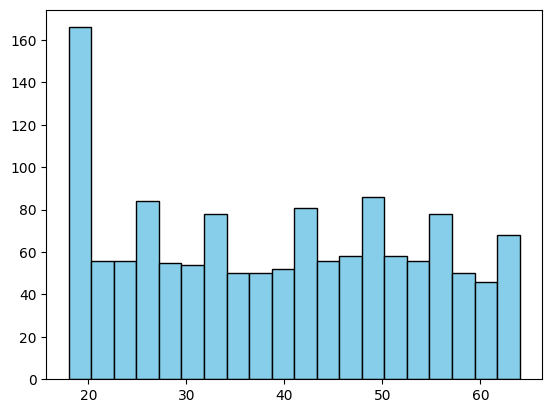

In [116]:
# distribution of age 
plt.hist(df['age'], bins=20, color='skyblue', edgecolor='black')
print(f"Mean age: {df['age'].mean()}, Max age: {df['age'].max()}, Min age: {df['age'].min()}")

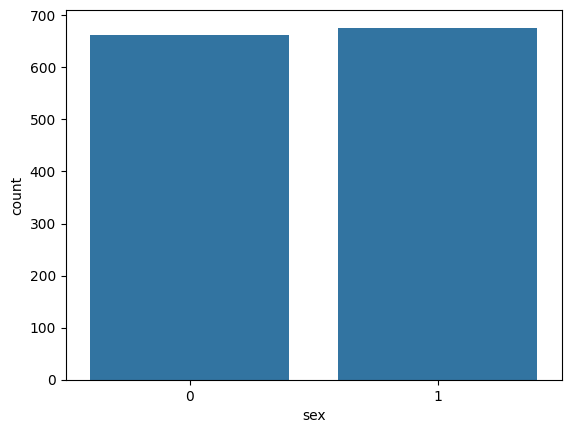

sex
1    676
0    662
Name: count, dtype: int64


In [117]:
# distribution of sex 
sns.countplot(x='sex', data=df)
plt.show()
print(df['sex'].value_counts())

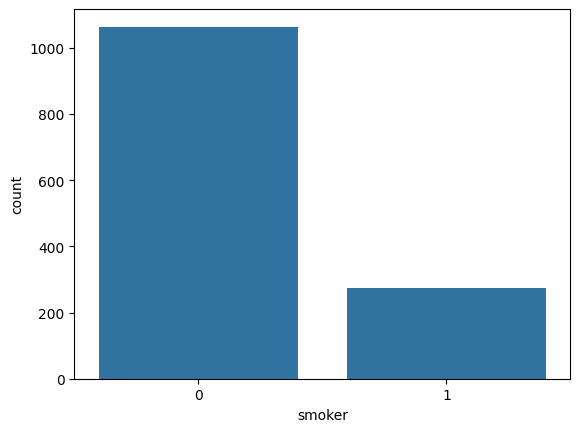

smoker
0    1064
1     274
Name: count, dtype: int64


In [118]:
#distribution of smoker 
sns.countplot(x='smoker', data=df)
plt.show()
print(df['smoker'].value_counts())

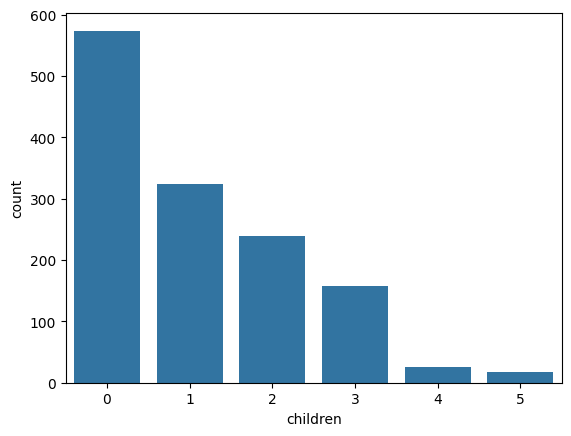

children
0    574
1    324
2    240
3    157
4     25
5     18
Name: count, dtype: int64


In [119]:
# distribution of children 
sns.countplot(x='children', data=df)
plt.show()
print(df['children'].value_counts())

can see bmi as following a normal distribution maybe ???? if that's the case we can use this fact to make future predictions

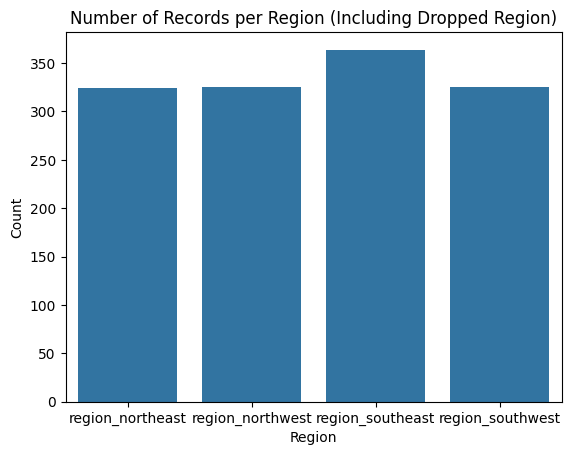

In [120]:
# plot distribution of regions 
# Identify one-hot encoded region columns
region_cols = [col for col in df.columns if col.startswith('region_')]

# Get counts for the encoded regions
region_counts = df[region_cols].sum()

# Compute count for the dropped region
base_region = 'region_northeast'  # <- replace with whichever region was dropped
base_region_count = len(df) - region_counts.sum()

# Add the dropped region to the count series
region_counts[base_region] = base_region_count

# Sort by region name (optional)
region_counts = region_counts.sort_index()

# Plot
sns.barplot(x=region_counts.index, y=region_counts.values)
plt.title('Number of Records per Region (Including Dropped Region)')
plt.xlabel('Region')
plt.ylabel('Count')
plt.show()

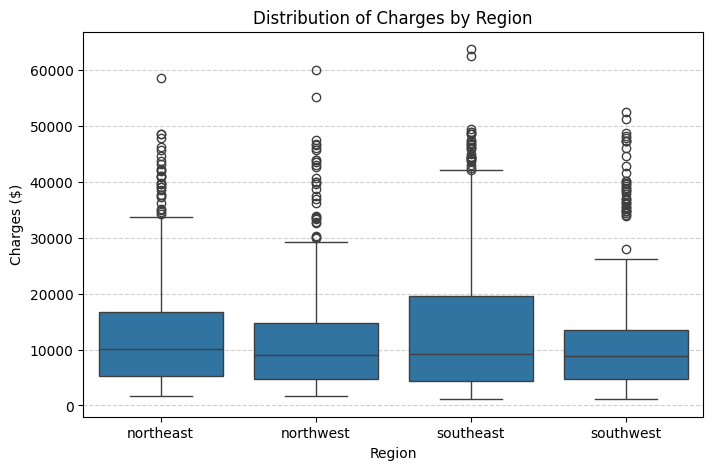

In [121]:
# Check if discrimination based on the region 
df['region'] = np.select(
    [df['region_northwest'], df['region_southeast'], df['region_southwest']],
    ['northwest', 'southeast', 'southwest'],
    default='northeast'   # baseline when none of the three dummies is True
)

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='region', y='charges', order=['northeast','northwest','southeast','southwest'])
plt.title('Distribution of Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

df.drop(columns=["region"], inplace=True)

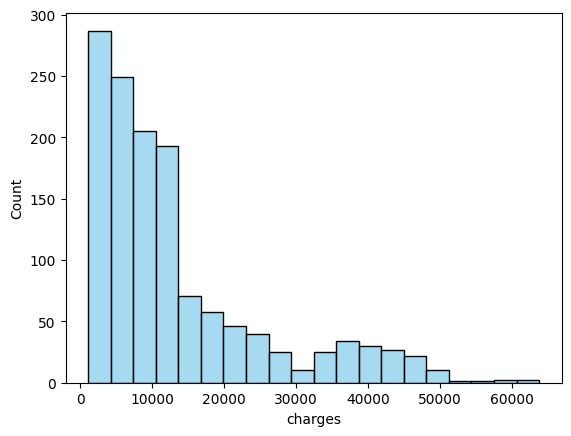

Mean charges: 13270.422265141257, Max charges: 63770.42801, Min charges: 1121.8739


In [122]:
#plot distribution of charges 
sns.histplot(df['charges'], bins=20, color='skyblue', edgecolor='black')
plt.show()
print(f"Mean charges: {df['charges'].mean()}, Max charges: {df['charges'].max()}, Min charges: {df['charges'].min()}")

<Axes: >

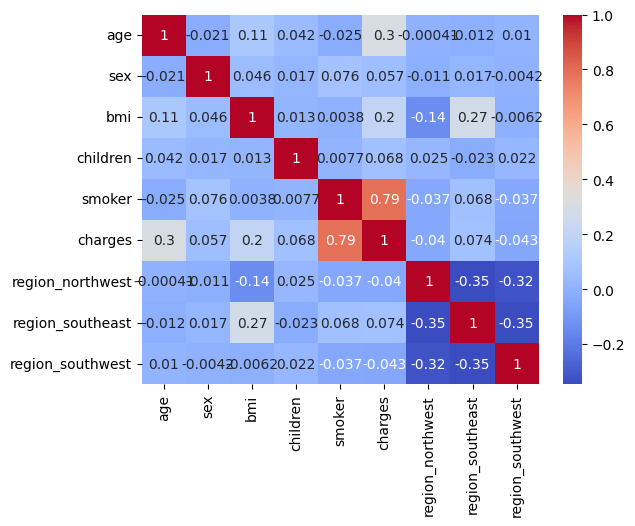

In [123]:
# correlation matrix 
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

In [124]:
# feature engineering 
df["smokerbmi"] = df["smoker"]*df["bmi"]
df["agechildren"] = df["age"]*df["children"]
df["agebmi"] = df["age"]*df["bmi"]
df["bmi_risk"] = ((df["bmi"] > 30) | (df["bmi"] < 18)).astype(int)

<Axes: >

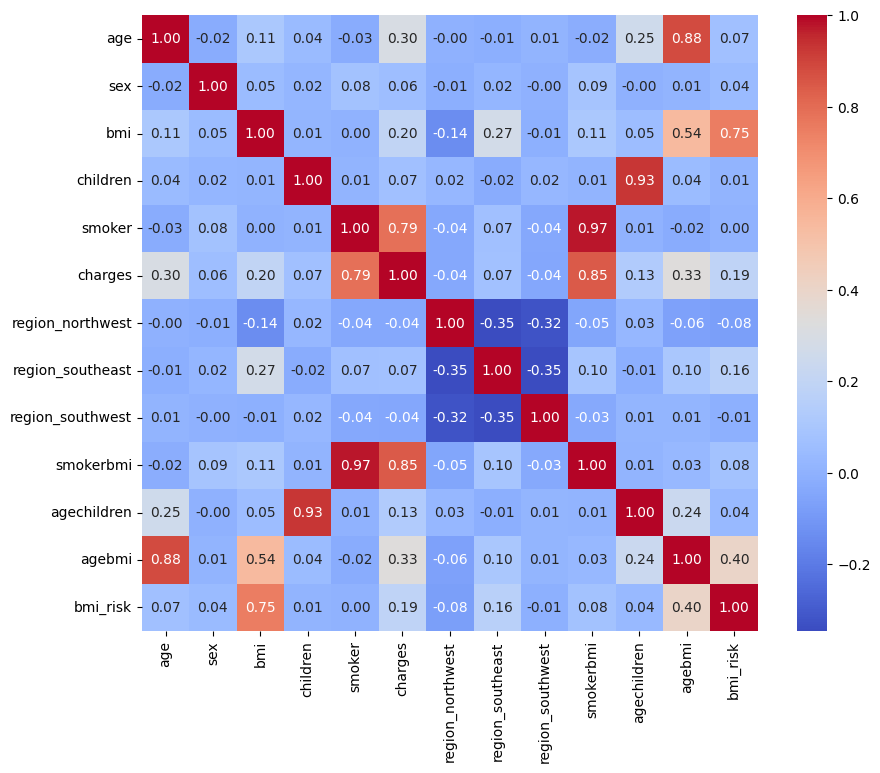

In [125]:
plt.figure(figsize=(10, 8))  # Increase figure size
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",         # Limit decimals
    cmap="coolwarm",
    annot_kws={"size": 10},  # Annotation font size
    square=True
)


mean charges males: 13956.751177721893
mean charges females: 12569.578843835347
median charges males: 9369.61575
median charges females: 9412.9625


/var/folders/56/1yfkkw_j243c09c394_fxr4c0000gn/T/ipykernel_94563/4162868290.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x='sex', y='charges', palette='Set2', width=0.5)


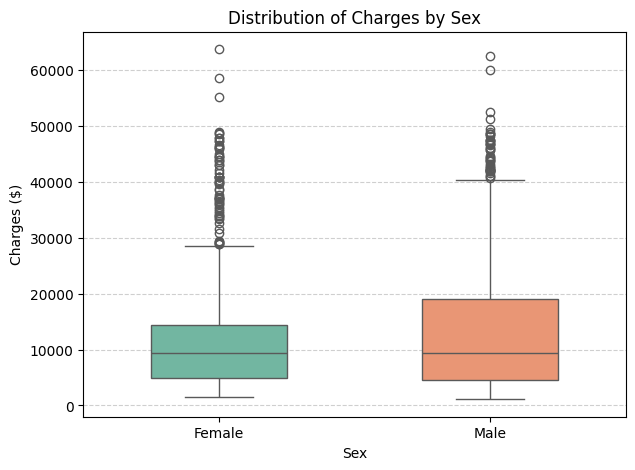

In [126]:
# spot differences in charges based on sex 
male_charges =  df.loc[df['sex'] == 1, 'charges']
female_charges = df.loc[df['sex'] == 0, 'charges']

mean_charges_males = np.mean(male_charges)
mean_charge_females = np.mean(female_charges)
print("mean charges males:", mean_charges_males)
print("mean charges females:", mean_charge_females)
print("median charges males:", np.median(male_charges))
print("median charges females:", np.median(female_charges))

df_plot = df[['sex', 'charges']].copy()
df_plot['sex'] = df_plot['sex'].map({1: 'Male', 0: 'Female'})

# Seaborn boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_plot, x='sex', y='charges', palette='Set2', width=0.5)

plt.title('Distribution of Charges by Sex')
plt.xlabel('Sex')
plt.ylabel('Charges ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

In [127]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(male_charges, female_charges, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.3f}")


T-statistic: 2.101, P-value: 0.036


this doesn't translate to any actual discrimination due to the presence of confounding variables that are actually determining the difference in prices. Can be seen in below models, in the feature importance analysis, that no importance is given to the variable sex.   

BASELINE MODEL

In [128]:
# train test split 
X = df.drop('charges', axis=1)
y = df['charges']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [129]:
# Linear Regression using all features 
X_train_used = X_train.drop(columns=['smokerbmi', 'agechildren', 'agebmi'], errors='ignore')
model = LinearRegression()
model.fit(X_train_used, y_train)

# evaluate the model 
X_test_used = X_test.drop(columns=['smokerbmi', 'agechildren', 'agebmi'], errors='ignore')
y_pred = model.predict(X_test_used)

# plot the results 
print(f"R-squared: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")

# get the coefficients 
coef_df = pd.DataFrame({
    'Feature': X_train_used.columns,
    'Coefficient': model.coef_
})
print(coef_df)

R-squared: 0.7860250009630461
Mean Squared Error: 33219347.17144056
            Feature   Coefficient
0               age    258.556456
1               sex    -28.991325
2               bmi    168.178532
3          children    411.709500
4            smoker  23624.132409
5  region_northwest   -380.416482
6  region_southeast   -520.870037
7  region_southwest   -790.921923
8          bmi_risk   2649.897364


In [130]:
# Linear Regression using only most correlated features, without considering feature engineer 
model1 = LinearRegression()
model1.fit(X_train[["smoker", "bmi", "age"]], y_train)

# evaluate the model 
y_pred1 = model1.predict(X_test[["smoker", "bmi", "age"]])

print(f"R-squared: {r2_score(y_test, y_pred1)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred1)}")

coef_df = pd.DataFrame({
    'Feature': X[["smoker", "bmi", "age"]].columns,
    'Coefficient': model1.coef_
})
print(coef_df)

R-squared: 0.7776932310583375
Mean Squared Error: 34512843.880227886
  Feature   Coefficient
0  smoker  23675.371847
1     bmi    326.450232
2     age    259.410205


In [131]:
# Linear Regression using only smoker 
model2 = LinearRegression()
model2.fit(X_train[["smoker"]], y_train)

# evaluate the model 
y_pred2 = model2.predict(X_test[["smoker"]])

print(f"R-squared: {r2_score(y_test, y_pred2)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred2)}")

print(f"Coefficient for smoker: {model2.coef_[0]}")

R-squared: 0.6602486589056529
Mean Squared Error: 52745964.72752624
Coefficient for smoker: 23188.68587068186


In [132]:
# Linear regression using smoker*bmi and age*children 
model3 = LinearRegression()
model3.fit(X_train[["smokerbmi", "agechildren"]], y_train)

# eval model 
y_pred3 = model3.predict(X_test[["smokerbmi", "agechildren"]])
print(f"R-squared: {r2_score(y_test, y_pred3)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred3)}")

print(f"Coefficients: {model3.coef_}")

R-squared: 0.7674088754764675
Mean Squared Error: 36109477.03852355
Coefficients: [795.30932611  28.97674503]


In [133]:
# Linear regression with log-transformation for "charges" -> doesn't perform well 
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

model4 = LinearRegression()
model4.fit(X_train, y_train_log)

y_pred4_log =model4.predict(X_test)
print(f"R-squared: {r2_score(np.exp(y_test_log), np.exp(y_pred4_log))}")
print(f"Mean Squared Error: {mean_squared_error(np.exp(y_test_log), np.exp(y_pred4_log))}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(np.exp(y_test_log), np.exp(y_pred4_log)))}")

R-squared: 0.4903707004824177
Mean Squared Error: 79119302.28114572
Root Mean Squared Error: 8894.903163112329


CLUSTERING

In [134]:
# Select relevant features for clustering
features = ["smoker"]
X = df[features].copy()


# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run K-Means (try 2 or 3 clusters)
kmeans = KMeans(n_clusters=2, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)

# Compute average charges per cluster
cluster_summary = df.groupby("cluster")["charges"].mean().reset_index()
print(cluster_summary)

   cluster       charges
0        0   8434.268298
1        1  32050.231832


RANDOM FOREST

📊 Model Performance:
   Metric        Value
R-squared 8.712620e-01
      MSE 1.998641e+07
     RMSE 4.470616e+03
      MAE 2.410233e+03

🌲 Feature Importances:
             Feature  Importance
8          smokerbmi    0.748153
0                age    0.097209
10            agebmi    0.061075
2                bmi    0.030923
9        agechildren    0.029037
4             smoker    0.007830
1                sex    0.004962
6   region_southeast    0.004520
3           children    0.004350
11          bmi_risk    0.004150
5   region_northwest    0.004056
7   region_southwest    0.003734


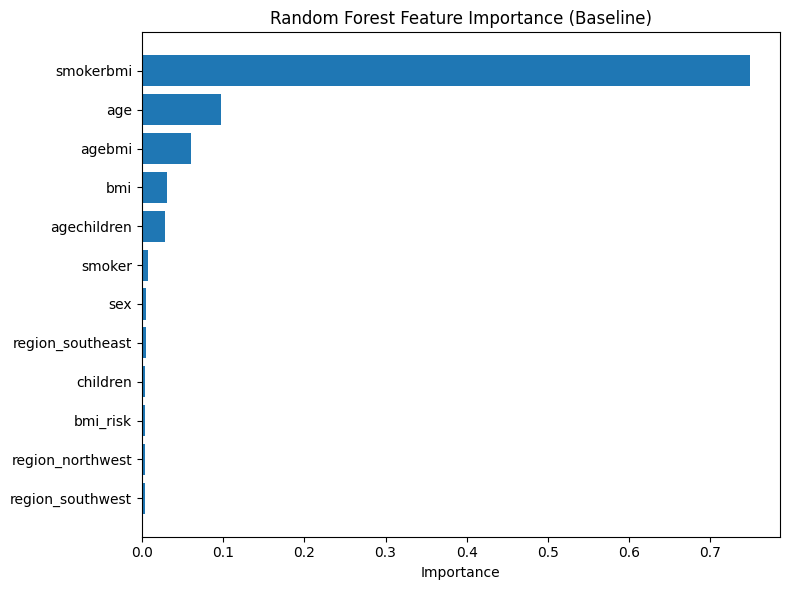

In [135]:
# baseline random forest model (no hyperparameter tuning)
rf1 = RandomForestRegressor()
rf1.fit(X_train, y_train)

y_pred = rf1.predict(X_test)

# --- Performance Metrics ---
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# Create a table of results
metrics_df = pd.DataFrame({
    'Metric': ['R-squared', 'MSE', 'RMSE', 'MAE'],
    'Value': [r2, mse, rmse, mae]
})

print("📊 Model Performance:")
print(metrics_df.to_string(index=False))

# --- Feature Importance ---
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf1.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n🌲 Feature Importances:")
print(importances)

# Plot Feature Importance
plt.figure(figsize=(8, 6))
plt.barh(importances['Feature'], importances['Importance'])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance (Baseline)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()


In [136]:
# hyperparameter tuning using GridSearch
# Define the model
rf2 = RandomForestRegressor()

# Define the parameter grid to search
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

# Randomized search (more efficient than full grid)
pipeline = GridSearchCV(
    estimator=rf2,
    param_grid=param_dist,
    cv=5,                 
    scoring='neg_mean_squared_error',          
    verbose=2,
    n_jobs=-1
)

# Fit on training data
pipeline.fit(X_train, y_train)

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.2s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=50; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.4s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 2, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [137]:
print("Best Parameters:", pipeline.best_params_)

# Evaluate on test data
best_rf = pipeline.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nTest Performance:")
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Parameters: {'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Test Performance:
R²: 0.8786850769229289
MSE: 18833987.91873737
RMSE: 4339.814272378182


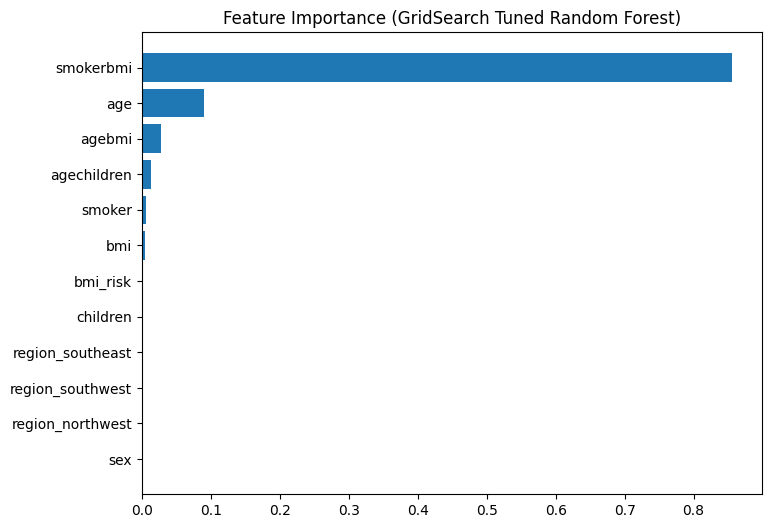

In [138]:
# plot feature importance 
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importances['Feature'], importances['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (GridSearch Tuned Random Forest)")
plt.show()

In [139]:
# hyperparameter tuning using BayesianSearch 
rf = RandomForestRegressor()

# Define the hyperparameter search space
search_spaces = {
    'n_estimators': Integer(100, 800),
    'max_depth': Integer(5, 40),
    'min_samples_split': Integer(2, 10),
    'min_samples_leaf': Integer(1, 5),
    'max_features': Categorical([None, 'sqrt', 'log2'])
}

# Set up the Bayesian optimization
opt = BayesSearchCV(
    estimator=rf,
    search_spaces=search_spaces,
    n_iter=30,                
    cv=5,                     
    scoring='neg_mean_squared_error',             
    n_jobs=-1,
    verbose=1,
    random_state=42
)

# Fit to training data
opt.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,RandomForestRegressor()
,search_spaces,"{'max_depth': Integer(low=5...m='normalize'), 'max_features': Categorical(c...), prior=None), 'min_samples_leaf': Integer(low=1...m='normalize'), 'min_samples_split': Integer(low=2...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,30
,scoring,'neg_mean_squared_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


Best Parameters: OrderedDict([('max_depth', 40), ('max_features', 'sqrt'), ('min_samples_leaf', 5), ('min_samples_split', 2), ('n_estimators', 800)])

Test Performance:
R²: 0.8804
MSE: 18562934.54
RMSE: 4308.47


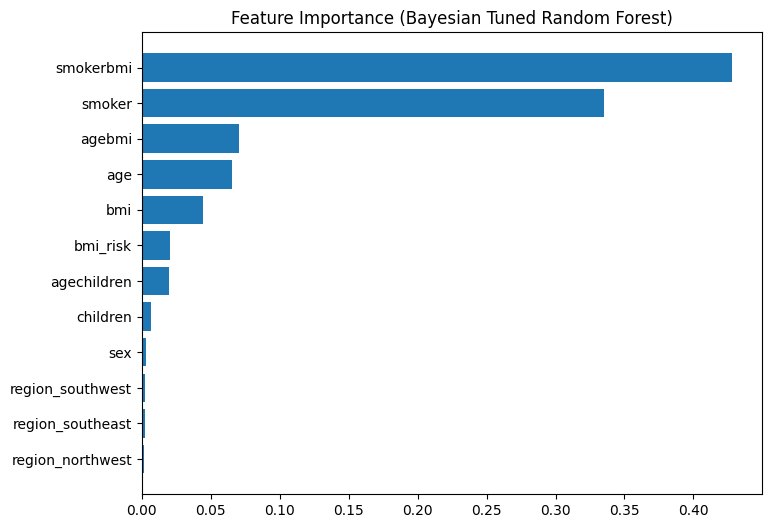

In [140]:
# Print best parameters and results
print("Best Parameters:", opt.best_params_)

# Evaluate on test data
best_rf = opt.best_estimator_
y_pred = best_rf.predict(X_test)

print("\nTest Performance:")
print(f"R²: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

# plot feature importance 
importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importances['Feature'], importances['Importance'])
plt.gca().invert_yaxis()
plt.title("Feature Importance (Bayesian Tuned Random Forest)")
plt.show()


XGBOOST

In [141]:
# baseline model 
xgb_model = XGBRegressor(random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test) 

print(f"R-squared: {r2_score(y_test, y_pred)}")
print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, y_pred))}")

NameError: name 'XGBRegressor' is not defined

In [ ]:
# hyperparameter tuning for xgboost 
xgb_model = XGBRegressor(random_state=42)

param_space = {
    "xgb__n_estimators": Integer(200, 1000),
    "xgb__max_depth": Integer(2, 8),
    "xgb__learning_rate": Real(0.01, 0.3, prior="log-uniform"),
    "xgb__subsample": Real(0.5, 1.0),
    "xgb__colsample_bytree": Real(0.5, 1.0),
    "xgb__gamma": Real(0, 5),
    "xgb__min_child_weight": Integer(1, 10)
}

opt = BayesSearchCV(
    estimator=xgb_model,
    search_spaces=param_space,
    n_iter=100,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1,
)

opt.fit(X_train, y_train)

# --- Best parameters ---
print("Best Parameters:")
print(opt.best_params_)

# --- Evaluate performance ---
y_pred = opt.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

best_model = opt.best_estimator_
all_feature_names = X_train.columns

# Plot importance
plt.figure(figsize=(10,6))
plt.barh(all_feature_names, best_model.feature_importances_)
plt.title("Feature Importance (XGBoost after tuning)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [ ]:
# hyperparamter tuning using GridSearch 
xgb_model = XGBRegressor(random_state=42)

param_grid = {
    "xgb__n_estimators": [300, 500],
    "xgb__max_depth": [3, 4, 6],
    "xgb__learning_rate": [0.01, 0.1],
    "xgb__subsample": [0.7, 1.0],
    "xgb__colsample_bytree": [0.7, 1.0],
    "xgb__min_child_weight": [1, 3],
    "xgb__gamma": [0, 0.5, 1.0]
}

gsearch = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="neg_mean_squared_error",  
    cv=5,
    n_jobs=-1,
    verbose=1
)

gsearch.fit(X_train, y_train)

# --- Performance ---
y_pred = gsearch.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Best Params:", gsearch.best_params_)
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.3f}")

# --- Feature importance ---
best_model = gsearch.best_estimator_
feature_names = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(feature_names, best_model.feature_importances_)
plt.title("Feature Importance (XGBoost • GridSearchCV)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


RANDOM FOREST USING 2 CLUSTERS FOUND 

In [153]:
# split two clusters into independent dataset and train two different models on them 
cluster1 = df[df["cluster"] == 0]
cluster2 = df[df["cluster"] == 1]


In [166]:
# train model on first cluster 
X = cluster1.drop("charges", axis=1)
y = cluster1["charges"]
X_train1, X_test1, y_train1, y_test1 = train_test_split(X, y, test_size=0.2)

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', "log2"]
}

opt1 = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                 
    scoring='neg_mean_squared_error',          
    verbose=2,
    n_jobs=-1
)

opt1.fit(X_train1, y_train1)

y_pred1 = opt1.predict(X_test1)

# evaluate model 
print("R-squared:", r2_score(y_test1, y_pred1))
print("RMSE:", np.sqrt(mean_squared_error(y_test1, y_pred1)))


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.6s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=

In [167]:
print(opt1.best_params_)

{'max_depth': 2, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}


In [144]:
# train model for cluster 2 
X = cluster2.drop("charges", axis=1)
y = cluster2["charges"]
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size = 0.2)

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 2, 5, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [None, 'sqrt', 'log2']
}

opt2 = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,                 
    scoring='neg_mean_squared_error',          
    verbose=2,
    n_jobs=-1
)

opt2.fit(X_train2, y_train2)

y_pred2 = opt2.predict(X_test2)

# evaluate model 
print("R-squared:", r2_score(y_test2, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y_test2, y_pred2)))


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.2s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.1s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   0.3s
[CV] END max_depth=None, max_features=None, min_samples_leaf=1, min_samples_split=

In [157]:
print(opt2.best_params_)

{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
